In [ ]:
!pip install torch_geometric

In [184]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, LayerNorm
from sklearn.metrics import f1_score
from torch.optim import lr_scheduler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import copy
import platform
import time
import matplotlib.pyplot as plt

# Specs

In [146]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [147]:
torch.cuda.get_device_name(0)

'Tesla T4'

In [148]:
SEED=25
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [149]:
print(f"OS = {platform.system()} {platform.release()}")
print(f"processor = {platform.system()}")

OS = Linux 6.6.113+
processor = Linux


# Loading data

In [292]:
edges = pd.read_csv('data/public/edges.csv')
nodes = pd.read_csv('data/public/nodes.csv')
train_df = pd.read_csv('data/public/train.csv')
val_df = pd.read_csv('data/public/val.csv')
test_nodes = pd.read_csv('data/public/test_nodes.csv')

# Data Preprocessing

In [257]:
print("Label Distribution Train")
print(train_df['diabetes'].value_counts(normalize=True))

Label Distribution Train
diabetes
0    0.87041
1    0.12959
Name: proportion, dtype: float64


In [258]:
print("Missing Values")
nodes.isnull().sum()

Missing Values


id                                0
age                               0
bmi                               0
HbA1c_level                   14368
blood_glucose_level               0
hypertension                      0
heart_disease                     0
gender_Female                     0
gender_Male                       0
smoking_history_current           0
smoking_history_non_smoker        0
smoking_history_past              0
HbA1c_missing                     0
dtype: int64

In [259]:
all_nodes_id = set(nodes["id"])
edge_nodes = set(edges['src']).union(set(edges['dst']))
missing_nodes = edge_nodes - all_nodes_id
missing_nodes
print(f"len of missing nodes {len(missing_nodes)}")

len of missing nodes 0


In [260]:
print("Feature Statistics")
nodes[['id','age','bmi','HbA1c_level','blood_glucose_level','hypertension',
            'heart_disease','gender_Female','gender_Male',	
            'smoking_history_current','smoking_history_non_smoker',
            'smoking_history_past','HbA1c_missing']].describe()

Feature Statistics


,id,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,gender_Female,gender_Male,smoking_history_current,smoking_history_non_smoker,smoking_history_past,HbA1c_missing
count,96128.000000,9.612800e+04,9.612800e+04,81760.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000,96128.000000
mean,48063.500000,1.626159e-18,-3.724643e-16,-0.001492,-0.000506,0.077615,0.040810,0.584231,0.415769,0.095675,0.699859,0.204467,0.149467
std,27749.907676,1.000005e+00,1.000005e+00,1.010939,1.011230,0.267567,0.197851,0.492857,0.492857,0.294146,0.458322,0.403314,0.356550
min,0.000000,-1.857108e+00,-2.557923e+00,-2.402041,-1.942696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24031.750000,-7.922561e-01,-5.794297e-01,-0.751066,-0.894935,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,48063.500000,5.357126e-02,-2.142881e-04,0.262415,0.074500,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,72095.250000,7.658470e-01,3.750937e-01,0.676628,0.498931,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,96127.000000,1.700709e+00,1.010207e+01,3.721737,4.467984,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Feature Engineering

In [261]:
nodes_df = nodes.copy()
# nodes_df["HbA1c_level"] = nodes_df["HbA1c_level"].fillna(0)
nodes_df['HbA1c_is_missing'] = nodes_df["HbA1c_level"].isna().astype(float)
median_hba1c = nodes_df["HbA1c_level"].median()
nodes_df["HbA1c_level"] = nodes_df["HbA1c_level"].fillna(median_hba1c)

In [262]:
feature_cols = [c for c in nodes_df.columns if c!='id']
x = torch.tensor(nodes_df[feature_cols].values, dtype=torch.float)
edge_index = torch.tensor(edges[['src','dst']].values.T,dtype=torch.long)

In [263]:
y = torch.full((len(nodes_df),),-1,dtype=torch.long)
y[train_df['id'].values] = torch.tensor(train_df['diabetes'].values, dtype=torch.long)
y[val_df['id'].values] = torch.tensor(val_df['diabetes'].values, dtype=torch.long)

In [264]:
train_mask = torch.zeros(len(nodes_df),dtype=torch.bool)
train_mask[train_df['id'].values] = True

In [265]:
val_mask = torch.zeros(len(nodes_df),dtype=torch.bool)
val_mask[val_df['id'].values] = True

In [266]:
data = Data(x=x,edge_index=edge_index,y=y,train_mask=train_mask,val_mask=val_mask)
data.to(device)

Data(x=[96128, 13], edge_index=[2, 1224756], y=[96128], train_mask=[96128], val_mask=[96128])

In [267]:
num_neg = (train_df['diabetes'] == 0).sum()
num_pos = (train_df['diabetes'] == 1).sum()
pos_weight = torch.tensor([num_neg / num_pos],dtype=torch.float).to(device)

In [268]:
print(f"graph data object: {data}")
print(f"cal positive lcass weight: {pos_weight.item():.2f}")

graph data object: Data(x=[96128, 13], edge_index=[2, 1224756], y=[96128], train_mask=[96128], val_mask=[96128])
cal positive lcass weight: 6.72


# Model Architecture

In [269]:
# class DiaGraphGAT(torch.nn.Module):
#     def __init__(self,in_channels, hidden_channels,out_channels,heads=4):
#         super(DiaGraphGAT,self).__init__()
#         self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, dropout=0.2)
#         self.conv2 = GATv2Conv(hidden_channels * heads,out_channels,heads=1,dropout = 0.2)

#     def forward(self,x,edge_index):
#         x = self.conv1(x,edge_index)
#         x = F.elu(x)
#         x = F.dropout(x,p=0.2,training=self.training)
#         x = self.conv2(x,edge_index)
#         return x

In [277]:
class DiaGraph_V2(torch.nn.Module):
    def __init__(self,in_channels,hidden_channels, out_channels, heads = 8):
        super(DiaGraph_V2, self).__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads, dropout=0.2)
        self.ln1 = LayerNorm(hidden_channels * heads)
        self.conv2 = GATv2Conv(hidden_channels * heads, hidden_channels, heads=heads, dropout=0.2)
        self.ln2 = LayerNorm(hidden_channels * heads)
        self.conv3 = GATv2Conv(hidden_channels * heads, out_channels, heads=1, dropout=0.2)

    def forward(self,x, edge_index):
        x_in = x
        x=self.conv1(x,edge_index)
        x = self.ln1(x)
        x=F.elu(x)

        x = self.conv2(x,edge_index)
        x = self.ln2(x)
        x=F.elu(x)

        x = self.conv3(x,edge_index)
        return x

In [278]:
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

In [279]:
model = DiaGraph_V2(in_channels=data.num_node_features,hidden_channels=32,out_channels=2)
model = model.to(device)
print(model)

DiaGraph_V2(
  (conv1): GATv2Conv(13, 32, heads=8)
  (ln1): LayerNorm(256, affine=True, mode=graph)
  (conv2): GATv2Conv(256, 32, heads=8)
  (ln2): LayerNorm(256, affine=True, mode=graph)
  (conv3): GATv2Conv(256, 2, heads=1)
)


In [280]:
#optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=5e-4) 
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-3) 
weights = torch.tensor([1.0,pos_weight.item()]).to(device)
criterion = torch.nn.CrossEntropyLoss(weight = weights)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

In [281]:
def train(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x,data.edge_index)
    loss = criterion(out[data.train_mask],data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

In [282]:
@torch.no_grad()
def test(model):
    model.eval()
    out = model(data.x,data.edge_index)
    pred = out.argmax(dim=1)
    y_true = data.y[data.val_mask].cpu()
    y_pred = pred[data.val_mask].cpu()
    val_f1 = f1_score(y_true,y_pred,average='macro');
    return val_f1

In [283]:
start_time = time.time()
best_f1 = 0
best_model_wtd = copy.deepcopy(model.state_dict())
loss_history = []
patience = 30
counter = 0
for epoch in range(1,401):
    loss = train(model)
    loss_history.append(loss)
    val_f1 = test(model)
    scheduler.step(val_f1)
    if val_f1 >best_f1:
        best_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
    if epoch % 10 == 0:
        curr_lr =  optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d} Loss {loss:.4f} Val-Macro-F1 {val_f1:.4f}")
    if counter >= patience:
        print("early stopping trigered")
        break

end_time = time.time()
print(f"Total trainig time = {end_time - start_time}")
print(f"Best f1 macro score = {best_f1}")

Epoch 010 Loss 0.5839 Val-Macro-F1 0.6845
Epoch 020 Loss 0.5408 Val-Macro-F1 0.6444
Epoch 030 Loss 0.5268 Val-Macro-F1 0.6931
Epoch 040 Loss 0.5220 Val-Macro-F1 0.7005
early stopping trigered
Total trainig time = 40.509374141693115
Best f1 macro score = 0.7340831933923647


# loading best model

In [284]:
model.load_state_dict(best_model_wts)

<All keys matched successfully>

In [285]:
model.eval()
with torch.no_grad():
    logits = model(data.x,data.edge_index)
    probs = torch.softmax(logits,dim=1)[data.val_mask][:,1].cpu().numpy()
    y_true = data.y[data.val_mask].cpu().numpy()

In [286]:

for ts in [0.5,0.55,0.6,0.65,0.7]:
    y_pred_ts = (probs > ts).astype(int)
    current_f1 = f1_score(y_true,y_pred_ts,average='macro')
    print(f"threshold = {ts} Macro f1 score = {current_f1:.4f}")

threshold = 0.5 Macro f1 score = 0.7341
threshold = 0.55 Macro f1 score = 0.7666
threshold = 0.6 Macro f1 score = 0.7961
threshold = 0.65 Macro f1 score = 0.8044
threshold = 0.7 Macro f1 score = 0.8195


# Plots

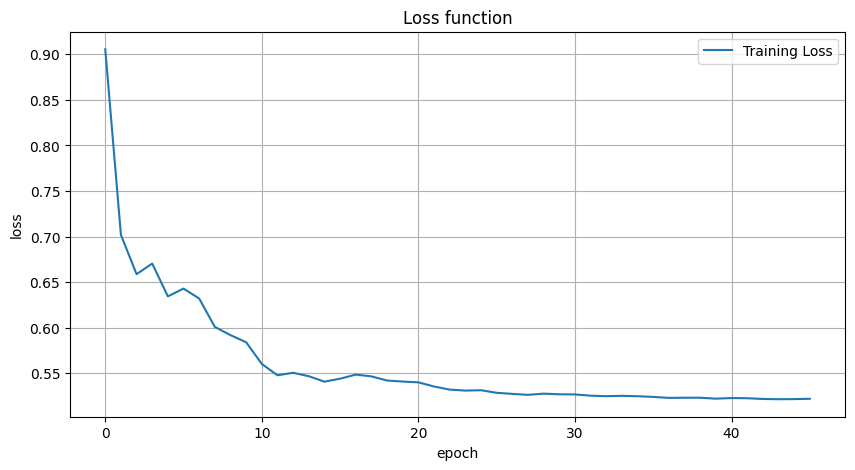

In [287]:
plt.figure(figsize=(10,5))
plt.plot(loss_history, label = "Training Loss")
plt.title("Loss function")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

 Model Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.99      0.88      0.93      8765
    Diabetes       0.42      0.89      0.57       848

    accuracy                           0.88      9613
   macro avg       0.70      0.89      0.75      9613
weighted avg       0.94      0.88      0.90      9613



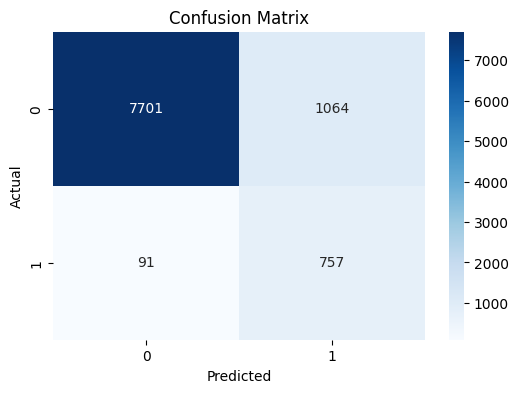

In [288]:
print(" Model Classification Report")
print(classification_report(y_true, y_pred, target_names=['No Diabetes', 'Diabetes']))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Generating sumbission file

In [293]:
test_ids = test_nodes['id'].values
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    all_probs = torch.softmax(logits,dim=1)[:,1].cpu().numpy()
test_probs = all_probs[test_ids]
a_probs = np.where(test_probs < 0.7, test_probs * (0.5 / 0.7), 0.5 + (test_probs - 0.7) * (0.5 / 0.3))
sub_file = pd.DataFrame({
    "id": test_ids,
    "y_pred": a_probs
})
submission_df.to_csv('predictions.csv',index = False)

In [294]:
df = pd.read_csv('predictions.csv')
df['y_pred'] =np.where(
    df['y_pred'] < 0.7, df['y_pred'] * (0.5/0.7),
    0.5 + (df['y_pred'] - 0.7) * (0.5/0.3)
)

df.to_csv('final_predictions.csv',index=False)